# Step 1 — Data Preprocessing and Preliminary Analysis

## 1. Objective and Context

The objective of this preprocessing phase is to prepare molecular dynamics simulation data for subsequent deep learning modeling.

The datasets describe the temporal evolution of a protein system through atomic coordinates, forces, and velocities.

The preprocessing aims to:
- verify data integrity and consistency,
- remove redundant or non-informative variables (timestamp),
- normalize the data to ensure numerical stability during training,
- preserve the physical meaning of the variables.

This step corresponds to **Step 1 (Import the data and check for errors and inconsistencies)** of the project workflow.

---

## 2. Datasets Description

Three datasets are considered:

| Dataset | Description | Raw Shape |
|---------|-------------|-----------|
| **coordinates.csv** | Atomic positions (x, y, z) over time | (50001, 415) |
| **forces.csv** | Atomic forces (x, y, z) over time | (50001, 415) |
| **velocity.csv** | Atomic velocities (x, y, z) over time | (50001, 415) |

Each dataset contains:
- 50,001 time steps
- 1 timestamp column (to be removed)
- 414 physical features (138 atoms × 3 spatial components)

---

## 3. Data Loading and Format Handling

The three datasets required different parsing strategies due to format inconsistencies:

| Dataset | Separator | Additional Issue |
|---------|-----------|------------------|
| coordinates.csv | `;` | None |
| forces.csv | `\t` (tab) | Spurious quote characters (`"`) |
| velocity.csv | `\t` (tab) | Spurious quote characters (`"`) |

A robust `read_dataset()` function was implemented to:
- automatically detect the correct separator,
- remove spurious quote characters from forces and velocity files,
- ensure consistent parsing across all datasets.

---

## 4. Timestamp Removal

All three datasets contain a timestamp column (column 0) with values starting at 0.000 and incrementing by Δt ≈ 0.002.

The timestamp was verified to be:
- strictly monotonic (always increasing),
- constant step size (Δt = 0.002),
- identical across all three datasets.

Since the temporal ordering is already encoded by the sequence index, the timestamp column was **removed from all datasets** before training. The timestamp was saved separately for potential analysis or visualization.

**Final shape after timestamp removal: (50001, 414) for all datasets.**

---

## 5. Data Cleaning

All datasets were checked for missing or invalid values:

| Check | Result |
|-------|--------|
| Missing values (NaN) | None found |
| Invalid entries | None found |
| Interpolation required | No |

This confirms the integrity of the molecular dynamics simulation output.

---

## 6. Feature Scaling

All physical variables were standardized using **StandardScaler** (Z-score normalization), applied independently to each dataset.

The transformation enforces:
- mean ≈ 0
- standard deviation ≈ 1

**Quality check results:**

| Dataset | Scaled Mean | Scaled Std | Status |
|---------|-------------|------------|--------|
| coordinates | ≈ 0 | ≈ 1 | ✓ |
| forces | ≈ 0 | ≈ 1 | ✓ |
| velocity | ≈ 0 | ≈ 1 | ✓ |

Feature scaling is essential to:
- ensure numerical stability during training,
- prevent dominance of variables with larger physical scales,
- allow fair comparison between different physical quantities.

The fitted scalers were saved as `.pkl` files for inverse transformation of predictions.

---

## 7. Distribution Analysis and Physical Interpretation

Standardization rescales the data but does not change the underlying distribution shape. The resulting distributions reflect the physical nature of each variable.

### 7.1 Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### 7.2 Forces (Quasi-Gaussian)
The distribution of forces is **approximately gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### 7.3 Velocity (Gaussian)
The distribution of velocities is **gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.

### Summary Table

| Dataset | Distribution Type | Physical Interpretation |
|---------|-------------------|------------------------|
| Velocity | Gaussian | Maxwell-Boltzmann equilibrium statistics |
| Forces | Quasi-Gaussian | Non-linear interactions with heavy tails |
| Coordinates | Non-Gaussian | Structural and conformational constraints |

---

## 8. Output Artifacts

All preprocessing artifacts were saved in the `processed_step1/` directory:

| File | Description |
|------|-------------|
| `{name}_clean.csv` | Cleaned data (timestamp removed) |
| `{name}_scaled.csv` | Standardized data (Z-score) |
| `{name}_time.csv` | Extracted timestamp (for reference) |
| `scaler_{name}.pkl` | Fitted StandardScaler object |
| `meta_{name}.json` | Metadata (shape, statistics, parameters) |

---

## 9. Quality Assessment Summary

| Requirement | Status |
|-------------|--------|
| Temporal consistency verified | ✓ |
| No missing or corrupted data | ✓ |
| Timestamp removed from all datasets | ✓ |
| All datasets aligned (50001 × 414) | ✓ |
| Feature scaling applied | ✓ |
| Physical meaning preserved | ✓ |
| Scalers saved for reproducibility | ✓ |

---

## 10. Conclusion

This preprocessing step successfully prepares the molecular dynamics datasets for deep learning applications.

Key accomplishments:
- Resolved format inconsistencies across the three source files
- Removed timestamp column uniformly from all datasets
- Verified physical consistency of the distributions
- Produced aligned, scaled datasets ready for model training

The processed datasets and corresponding scalers are now ready for **Step 2: Dataset Construction** (dimensionality reduction and windowing).

## Random Seed Configuration

To ensure reproducibility of all experiments, random seeds are fixed at the beginning of the pipeline.

| Library | Seed Value |
|---------|------------|
| NumPy | 42 |
| Python random | 42 |

This guarantees that any random operations (e.g., sampling for visualization) produce consistent results across different runs.

In [3]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## Preprocessing Functions Definition

This cell defines the core functions for the preprocessing pipeline:

### `read_dataset(path)`
Handles the different file formats present in the source data:
- First attempts parsing with semicolon (`;`) separator (used by `coordinates.csv`)
- If that fails, reads the file as text and removes spurious quote characters (`"`)
- Then attempts tab (`\t`) or whitespace separation (used by `forces.csv` and `velocity.csv`)

This robust approach ensures consistent loading regardless of format inconsistencies.

### `summarize_time(series)`
Analyzes the timestamp column to verify temporal consistency:
- Checks if values are numeric and strictly monotonic
- Computes the time step (Δt) statistics (median, min, max)
- Returns a dictionary with temporal metadata for quality assessment

### `clean_and_scale(df)`
Performs data cleaning and standardization:
- Converts all values to numeric type
- **Removes column 0 (timestamp) from all datasets**
- Handles missing values via linear interpolation (if any)
- Applies **StandardScaler** (Z-score normalization)
- Computes descriptive statistics before and after scaling

### `save_artifacts(base_name, result, meta)`
Saves all preprocessing outputs to the `processed_step1/` directory:
- `{name}_clean.csv`: Cleaned features (timestamp removed)
- `{name}_scaled.csv`: Standardized features
- `{name}_time.csv`: Extracted timestamp
- `scaler_{name}.pkl`: Fitted scaler (for inverse transform)
- `meta_{name}.json`: Metadata and statistics

In [27]:
import os
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

INPUT_FILES = ["coordinates.csv", "forces.csv", "velocity.csv"]
OUT_DIR = "processed_step1"
os.makedirs(OUT_DIR, exist_ok=True)

def read_dataset(path):
    """
    Reads the dataset handling different formats.
    Removes spurious quotes and identifies the correct separator.
    """
    # First try with semicolon separator
    df1 = pd.read_csv(path, sep=";", header=None, engine="python")
    if df1.shape[1] > 1:
        return df1, ";"
    
    # Otherwise read as text and clean quotes
    with open(path, 'r') as f:
        lines = f.readlines()
    
    # Remove quotes from each line
    cleaned_lines = [line.replace('"', '').strip() for line in lines]
    
    # Rebuild as dataframe using tab or whitespace
    from io import StringIO
    cleaned_text = '\n'.join(cleaned_lines)
    
    # Try with tab
    df2 = pd.read_csv(StringIO(cleaned_text), sep="\t", header=None, engine="python")
    if df2.shape[1] > 1:
        return df2, "\\t (cleaned)"
    
    # Otherwise whitespace
    df3 = pd.read_csv(StringIO(cleaned_text), sep=r"\s+", header=None, engine="python")
    return df3, "whitespace (cleaned)"


def summarize_time(series):
    t = pd.to_numeric(series, errors="coerce")
    ok_numeric = float(t.isna().mean()) == 0.0
    mono = bool(t.is_monotonic_increasing) if ok_numeric else False
    head = t.head(5).tolist() if ok_numeric else series.head(5).tolist()
    tail = t.tail(5).tolist() if ok_numeric else series.tail(5).tolist()
    dt = np.diff(t.values) if ok_numeric and len(t) > 1 else np.array([])
    dt_median = float(np.median(dt)) if dt.size > 0 else None
    dt_min = float(np.min(dt)) if dt.size > 0 else None
    dt_max = float(np.max(dt)) if dt.size > 0 else None
    return {
        "time_numeric": bool(ok_numeric),
        "time_monotonic": bool(mono),
        "time_head": head,
        "time_tail": tail,
        "dt_median": dt_median,
        "dt_min": dt_min,
        "dt_max": dt_max
    }

def clean_and_scale(df, scaling_method="per_feature"):
    """
    Cleans and scales the dataframe.
    
    scaling_method:
        - "per_feature": (RACCOMANDATO) StandardScaler indipendente per ogni colonna.
                         Essenziale per Gradient Descent e Autoencoders.
        - "global": un solo mean/std per tutto il dataset (preserva rapporti metrici 
                    ma rischioso per convergenza ML se le feature hanno range diversi).
        - "none": nessuna normalizzazione.
    """
    # 1. Conversione in numerico e pulizia base
    df_num = df.apply(pd.to_numeric, errors="coerce")
    df_num = df_num.dropna(axis=1, how="all")

    # 2. Separazione Tempo e Features
    # Assumiamo colonna 0 = Timestamp, colonne 1: = Features
    time = df_num.iloc[:, 0].copy()
    X = df_num.iloc[:, 1:].copy()

    nan_before = int(X.isna().sum().sum())
    
    # 3. Interpolazione (gestione buchi temporali brevi)
    if nan_before > 0:
        X = X.interpolate(method="linear", limit_direction="both")

    # Rimuove colonne rimaste completamente vuote o NaN
    X = X.dropna(axis=1, how="all")
    nan_after = int(X.isna().sum().sum())

    # Reset indice per allineamento
    X_clean = X.reset_index(drop=True)
    
    # === SCALING ===
    if scaling_method == "per_feature":
        # Standardizzazione colonna per colonna (Media=0, Std=1 per ogni feature)
        # Questo è il metodo standard per Reti Neurali / PCA
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled_vals = scaler.fit_transform(X_clean.values)
        
    elif scaling_method == "global":
        # Normalizzazione GLOBALE (Preserva le proporzioni relative ma non centra le singole feature)
        global_mean = X_clean.values.mean()
        global_std = X_clean.values.std()
        X_scaled_vals = (X_clean.values - global_mean) / global_std
        
        # Creiamo un oggetto "simil-scaler" per salvare i parametri
        scaler = {"method": "global", "mean": global_mean, "std": global_std}
        
    else:  # "none"
        X_scaled_vals = X_clean.values
        scaler = {"method": "none"}

    # Ricostruzione DataFrame mantenendo i nomi colonne originali
    X_scaled_df = pd.DataFrame(X_scaled_vals, columns=[str(c) for c in X_clean.columns])

    # Calcolo statistiche per Meta-data
    stats_clean = X_clean.describe().T[["mean", "std", "min", "max"]]
    stats_scaled = X_scaled_df.describe().T[["mean", "std", "min", "max"]]

    return {
        "X_clean": X_clean,
        "X_scaled": X_scaled_df,
        "time": time,
        "scaler": scaler,
        "nan_before": nan_before,
        "nan_after": nan_after,
        "clean_stats": {
            "mean_global": float(stats_clean["mean"].mean()),
            "std_global": float(stats_clean["std"].mean()),
            "min_global": float(stats_clean["min"].min()),
            "max_global": float(stats_clean["max"].max())
        },
        "scaled_stats": {
            "mean_global": float(stats_scaled["mean"].mean()),
            "std_global": float(stats_scaled["std"].mean()),
            "min_global": float(stats_scaled["min"].min()),
            "max_global": float(stats_scaled["max"].max())
        }
    }


def save_artifacts(base_name, result, meta):
    clean_csv = os.path.join(OUT_DIR, f"{base_name}_clean.csv")
    scaled_csv = os.path.join(OUT_DIR, f"{base_name}_scaled.csv")
    scaler_pkl = os.path.join(OUT_DIR, f"scaler_{base_name}.pkl")
    meta_json = os.path.join(OUT_DIR, f"meta_{base_name}.json")
    time_csv = os.path.join(OUT_DIR, f"{base_name}_time.csv")

    result["X_clean"].to_csv(clean_csv, index=False)
    result["X_scaled"].to_csv(scaled_csv, index=False)
    joblib.dump(result["scaler"], scaler_pkl)

    if result["time"] is not None:
        pd.Series(result["time"]).to_csv(time_csv, index=False, header=False)

    with open(meta_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    return {
        "clean_csv": clean_csv,
        "scaled_csv": scaled_csv,
        "scaler_pkl": scaler_pkl,
        "meta_json": meta_json,
        "time_csv": time_csv if result["time"] is not None else None
    }

## File Structure Diagnostic

This cell performs a detailed inspection of the raw file structure before preprocessing.

### Purpose

Verify that data loading and quote cleaning worked correctly by examining:
- **Separator detected**: Confirms correct parsing strategy was applied
- **Shape**: Raw dimensions of each dataset
- **Column 0**: Should contain timestamp values (0.000, 0.002, 0.004, ...)
- **Column 1**: First actual feature (should be numeric physical data)
- **Last column**: Verifies no trailing artifacts or quote characters
- **NaN columns**: Identifies any completely empty columns
- **Data type**: Confirms numeric parsing succeeded

### Expected Results

| Dataset | Separator | Column 0 (timestamp) | Issues |
|---------|-----------|---------------------|--------|
| coordinates.csv | `;` | [0.0, 0.002, ...] | None |
| forces.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |
| velocity.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |

This diagnostic confirms that the `read_dataset()` function correctly handles format inconsistencies across the source files.

In [16]:
print("=== FILE STRUCTURE DIAGNOSTIC ===\n")

for f in INPUT_FILES:
    df, sep = read_dataset(f)
    print(f"FILE: {f}")
    print(f"  Separator: {sep}")
    print(f"  Shape: {df.shape}")
    print(f"  Column 0 (first 5 rows): {df.iloc[:5, 0].tolist()}")
    print(f"  Column 1 (first 5 rows): {df.iloc[:5, 1].tolist()}")
    print(f"  Last column (first 5 rows): {df.iloc[:5, -1].tolist()}")
    
    nan_cols = df.columns[df.isna().all()].tolist()
    print(f"  Fully NaN columns: {nan_cols}")
    
    print(f"  Column 0 dtype: {df.iloc[:, 0].dtype}")
    print()

=== FILE STRUCTURE DIAGNOSTIC ===

FILE: coordinates.csv
  Separator: ;
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [56.398, 56.3992, 56.3999, 56.4001, 56.4001]
  Last column (first 5 rows): [52.421, 52.4215, 52.4222, 52.4229, 52.4236]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: forces.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [-1145.43, -1888.0, -1840.93, -1041.78, 97.5775]
  Last column (first 5 rows): [847.998, 625.43, 258.009, -139.416, -441.616]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: velocity.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [0.7728, 0.612864, 0.352195, 0.111483, -0.0193876]
  Last column (first 5 rows): [0.1593, 0.265599, 0.332929, 0.36518, 0.347753]
  Fully NaN columns: []
  Column 

## Execute Preprocessing Pipeline

This cell runs the complete preprocessing pipeline on all three datasets.

### Processing Steps (for each dataset)

1. **File Validation**: Check that input files exist
2. **Data Loading**: Read dataset using the robust `read_dataset()` function
3. **Timestamp Analysis**: Extract temporal metadata from column 0
4. **Cleaning & Scaling**: Remove timestamp, handle NaN values, apply StandardScaler
5. **Save Artifacts**: Export all outputs to `processed_step1/` directory
6. **Logging**: Print detailed summary for each dataset

### Output Verification

For each dataset, the pipeline verifies and reports:
- **Raw Shape**: Original dimensions (should be 50001 × 415)
- **Final Shape**: After timestamp removal (should be 50001 × 414)
- **Time Monotonic**: Confirms timestamp is strictly increasing
- **NaN Count**: Before and after cleaning (expected: 0)
- **Scaled Statistics**: Mean ≈ 0 and Std ≈ 1 confirms correct standardization

### Summary DataFrame

The final `summary_df` table collects all metadata for quick comparison across datasets, enabling automated quality checks in the next cell.

In [28]:
rows = []

print(f"Processing files in: {INPUT_FILES}")
print(f"Output directory: {OUT_DIR}")

for f in INPUT_FILES:
    if not os.path.exists(f):
        print(f"Skipping {f}, file not found.")
        continue

    base = os.path.splitext(os.path.basename(f))[0].lower()
    df, sep_used = read_dataset(f)

    # Analisi temporale
    time_info = summarize_time(df.iloc[:, 0])

    # === PUNTO CRITICO: USIAMO PER_FEATURE SCALING ===
    # Questo assicura che Forces, Velocity e Coords abbiano tutte media 0 e std 1
    # indipendentemente dalle loro unità di misura o scale originali.
    res = clean_and_scale(df, scaling_method="per_feature")

    meta = {
        "file": f,
        "base_name": base,
        "separator_used": sep_used,
        "raw_shape": [int(df.shape[0]), int(df.shape[1])],
        "final_shape": [int(res["X_scaled"].shape[0]), int(res["X_scaled"].shape[1])],
        "time_info": time_info,
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_stats": res["clean_stats"],
        "scaled_stats": res["scaled_stats"]
    }

    paths = save_artifacts(base, res, meta)

    print("\n" + "=" * 80)
    print("DATASET:", f)
    print("SEP:", sep_used)
    print("RAW SHAPE:", meta["raw_shape"])
    print("FINAL SHAPE:", meta["final_shape"])
    print("SCALING METHOD:", "per_feature (StandardScaler)")
    print("NaN BEFORE/AFTER:", int(res["nan_before"]), "/", int(res["nan_after"]))
    
    # Verifica rapida che lo scaling abbia funzionato (dovrebbero essere ~0 e ~1)
    print(f"SCALED GLOBAL MEAN: {res['scaled_stats']['mean_global']:.6f} (Target: ~0.0)")
    print(f"SCALED GLOBAL STD:  {res['scaled_stats']['std_global']:.6f} (Target: ~1.0)")
    
    print("OUT META:", paths["meta_json"])

    rows.append({
        "dataset": f,
        "sep": sep_used,
        "raw_shape": meta["raw_shape"],
        "final_shape": meta["final_shape"],
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_min": res["clean_stats"]["min_global"],
        "clean_max": res["clean_stats"]["max_global"],
        "scaled_mean_global": res["scaled_stats"]["mean_global"],
        "scaled_std_global": res["scaled_stats"]["std_global"],
        "clean_csv": paths["clean_csv"],
        "scaled_csv": paths["scaled_csv"],
        "scaler_pkl": paths["scaler_pkl"]
    })

summary_df = pd.DataFrame(rows)
print("\nProcessing Complete.")
# print(summary_df) # Decommenta se vuoi vedere la tabella finale in console

Processing files in: ['coordinates.csv', 'forces.csv', 'velocity.csv']
Output directory: processed_step1

DATASET: coordinates.csv
SEP: ;
RAW SHAPE: [50001, 415]
FINAL SHAPE: [50001, 414]
SCALING METHOD: per_feature (StandardScaler)
NaN BEFORE/AFTER: 0 / 0
SCALED GLOBAL MEAN: -0.000000 (Target: ~0.0)
SCALED GLOBAL STD:  1.000010 (Target: ~1.0)
OUT META: processed_step1\meta_coordinates.json

DATASET: forces.csv
SEP: \t (cleaned)
RAW SHAPE: [50001, 415]
FINAL SHAPE: [50001, 414]
SCALING METHOD: per_feature (StandardScaler)
NaN BEFORE/AFTER: 0 / 0
SCALED GLOBAL MEAN: 0.000000 (Target: ~0.0)
SCALED GLOBAL STD:  1.000010 (Target: ~1.0)
OUT META: processed_step1\meta_forces.json

DATASET: velocity.csv
SEP: \t (cleaned)
RAW SHAPE: [50001, 415]
FINAL SHAPE: [50001, 414]
SCALING METHOD: per_feature (StandardScaler)
NaN BEFORE/AFTER: 0 / 0
SCALED GLOBAL MEAN: 0.000000 (Target: ~0.0)
SCALED GLOBAL STD:  1.000010 (Target: ~1.0)
OUT META: processed_step1\meta_velocity.json

Processing Complete.


## Outlier Analysis

Before confirming that Z-score normalization is appropriate, we analyze the cleaned (but not yet scaled) data for extreme outliers. This analysis is performed on the original value ranges to determine if StandardScaler is suitable or if a more robust method would be needed.

We examine how many values fall beyond typical thresholds, calculated using the mean and standard deviation of each feature.

In [29]:
print("=== OUTLIER ANALYSIS (on cleaned data) ===\n")

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    
    # Calculate z-scores manually to find outliers
    mean = df.mean()
    std = df.std()
    z_scores = (df - mean) / std
    
    total = df.size
    
    # Count values beyond thresholds
    beyond_3 = (z_scores.abs() > 3).sum().sum()
    beyond_4 = (z_scores.abs() > 4).sum().sum()
    beyond_5 = (z_scores.abs() > 5).sum().sum()
    
    print(f"{name}:")
    print(f"  Total values: {total:,}")
    print(f"  Beyond ±3σ: {beyond_3:,} ({100*beyond_3/total:.4f}%)")
    print(f"  Beyond ±4σ: {beyond_4:,} ({100*beyond_4/total:.4f}%)")
    print(f"  Beyond ±5σ: {beyond_5:,} ({100*beyond_5/total:.4f}%)")
    
    if beyond_5 / total < 0.001:
        print(f"  No extreme outliers detected")
    else:
        print(f"  Significant outliers detected")
    print()

=== OUTLIER ANALYSIS (on cleaned data) ===

coordinates:
  Total values: 20,700,414
  Beyond ±3σ: 0 (0.0000%)
  Beyond ±4σ: 0 (0.0000%)
  Beyond ±5σ: 0 (0.0000%)
  No extreme outliers detected

forces:
  Total values: 20,700,414
  Beyond ±3σ: 118,453 (0.5722%)
  Beyond ±4σ: 10,640 (0.0514%)
  Beyond ±5σ: 961 (0.0046%)
  No extreme outliers detected

velocity:
  Total values: 20,700,414
  Beyond ±3σ: 80,058 (0.3867%)
  Beyond ±4σ: 4,406 (0.0213%)
  Beyond ±5σ: 241 (0.0012%)
  No extreme outliers detected



## Preprocessing Quality Check

This cell performs automated validation of the preprocessing results.

### Validation Criteria

| Check | Condition | Purpose |
|-------|-----------|---------|
| `ok_mean` | \|mean\| < 0.05 | Confirms data is centered near zero |
| `ok_std` | \|std - 1.0\| < 0.05 | Confirms unit variance normalization |
| `ok_nan` | NaN count = 0 | Confirms no missing values remain |
| `preprocessing_ok` | All checks pass | Global quality flag |

### Expected Results

All three datasets should show `True` for all checks, confirming that:
- StandardScaler was applied correctly
- No data corruption occurred during processing
- Datasets are ready for model training

If any check fails, the preprocessing pipeline should be investigated before proceeding to Step 2.

In [30]:
summary_df["ok_mean"] = summary_df["scaled_mean_global"].abs() < 0.05
summary_df["ok_std"] = (summary_df["scaled_std_global"] - 1.0).abs() < 0.05
summary_df["ok_nan"] = summary_df["nan_after"] == 0
summary_df["preprocessing_ok"] = summary_df["ok_mean"] & summary_df["ok_std"] & summary_df["ok_nan"]
summary_df


,dataset,sep,raw_shape,final_shape,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl,ok_mean,ok_std,ok_nan,preprocessing_ok
0,coordinates.csv,;,"[50001, 415]","[50001, 414]",0,0,20.69030,57.03940,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl,True,True,True,True
1,forces.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-6772.97000,6400.45000,2.061434e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl,True,True,True,True
2,velocity.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-8.77941,7.76788,7.320246e-19,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl,True,True,True,True


## Output Shape Verification

This cell performs a final check to confirm that all processed datasets have the expected dimensions.

### Expected Output

All three datasets should have identical shapes:

| Dataset | Expected Shape |
|---------|---------------|
| coordinates | (50001, 414) |
| forces | (50001, 414) |
| velocity | (50001, 414) |

Where:
- **50001** = number of timesteps in the MD simulation
- **414** = number of features (138 atoms × 3 spatial components)

This confirms that the timestamp column was correctly removed from all datasets and that they are now aligned for subsequent concatenation and model training.

In [31]:
import pandas as pd

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    print(name, df.shape)


coordinates (50001, 414)
forces (50001, 414)
velocity (50001, 414)


---
---
---

## Timestamp Consistency Verification

This cell visualizes the extracted timestamp to verify temporal consistency of the MD simulation.

### Purpose

Before using the data for deep learning, it is essential to verify that the timestamp:
- Is **monotonically increasing** (no jumps backward in time)
- Has a **constant time step** (uniform sampling rate)

### Expected Result

The plot should show a **straight diagonal line**, indicating:
- Linear time progression from t=0 to t≈4 (for the first 2000 samples)
- Constant step size Δt ≈ 0.002 between consecutive frames

This confirms the temporal coherence of the molecular dynamics simulation and validates that the timestamp was correctly extracted during preprocessing.

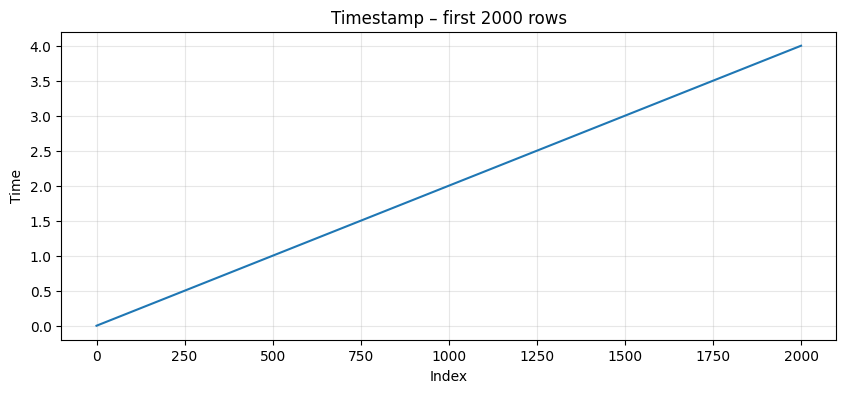

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = pd.read_csv("processed_step1/coordinates_time.csv", header=None).iloc[:, 0].values
dt = np.diff(t)

plt.figure(figsize=(10,4))
plt.plot(t[:2000])
plt.title("Timestamp – first 2000 rows")
plt.xlabel("Index")
plt.ylabel("Time")
plt.grid(True, alpha=0.3)
plt.show()



## Feature Distribution: Before vs After Scaling

This cell visualizes the effect of StandardScaler on individual features.

### Purpose

Compare the distribution of a single feature before and after Z-score normalization to verify that:
- The **shape** of the distribution is preserved (scaling does not alter the underlying data structure)
- The **location** is shifted to zero mean
- The **scale** is normalized to unit variance

### Interpretation

| Plot | X-axis | Expected Range |
|------|--------|----------------|
| Left (original) | Physical units (Å) | Dataset-dependent (e.g., 20-57 for coordinates) |
| Right (scaled) | Z-score (dimensionless) | Approximately -3 to +3 |

The distribution shape should be **identical** in both plots — only the axis scale changes. This confirms that StandardScaler correctly transforms the data without introducing distortions.

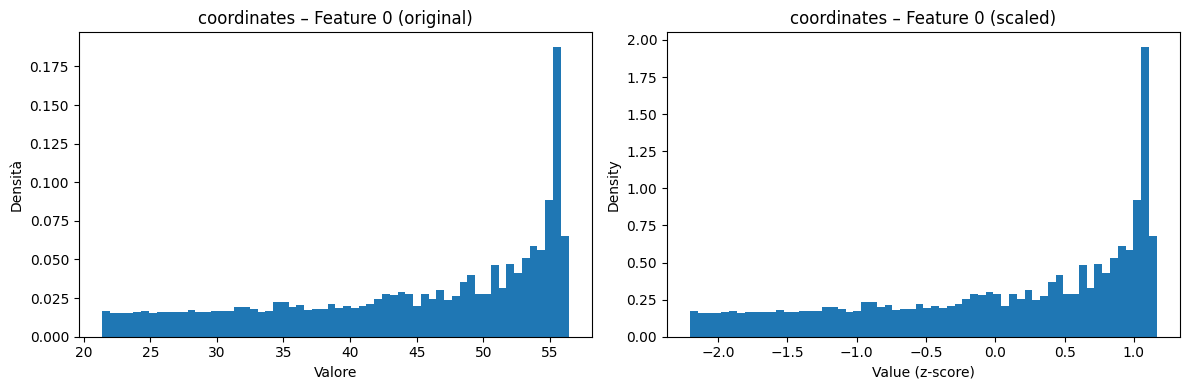

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_before_after(dataset, col_idx=0):
    clean = pd.read_csv(f"processed_step1/{dataset}_clean.csv")
    scaled = pd.read_csv(f"processed_step1/{dataset}_scaled.csv")

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(clean.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (original)")
    plt.xlabel("Valore")
    plt.ylabel("Densità")

    plt.subplot(1,2,2)
    plt.hist(scaled.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (scaled)")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

plot_before_after("coordinates", 0)


## Temporal Evolution of a Single Feature

This cell visualizes the time-series behavior of an individual feature to verify data integrity.

### Purpose

Verify that the feature varies over time in a **continuous and physically plausible** manner, without:
- Sudden discontinuities or jumps
- Constant flat regions (which would indicate missing data)
- Artifacts introduced by preprocessing

### Expected Result

For **velocity** features, the plot should show:
- **Stochastic oscillations** around zero (characteristic of MD simulations at thermal equilibrium)
- **Continuous signal** with no abrupt jumps
- **Amplitude** consistent with typical atomic velocities

### Interpretation

A smooth, oscillating pattern confirms that:
1. The preprocessing did not introduce artifacts
2. The data correctly represents physical molecular dynamics
3. The feature is ready for sequence-based model training

**Note**: If this plot shows a straight diagonal line instead of oscillations, it indicates that the timestamp column was not correctly removed — this was the bug we fixed earlier in the preprocessing pipeline.

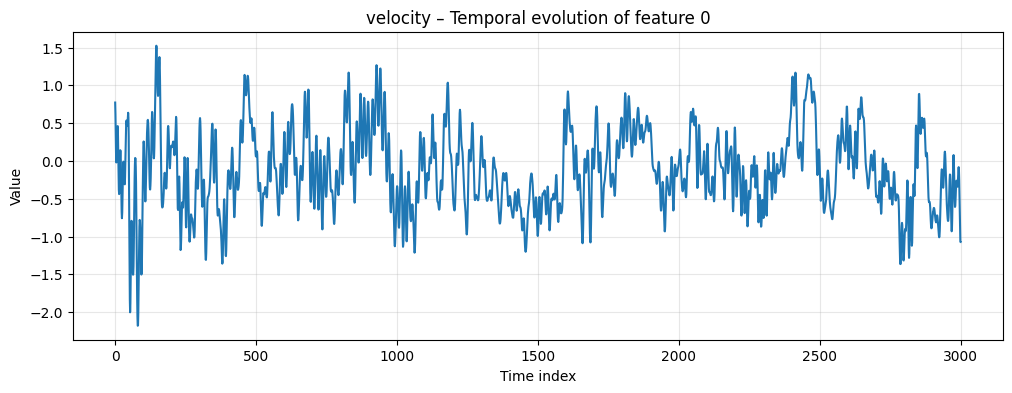

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series(dataset, col_idx=0, n_points=3000):
    df = pd.read_csv(f"processed_step1/{dataset}_clean.csv")

    plt.figure(figsize=(12,4))
    plt.plot(df.iloc[:n_points, col_idx])
    plt.title(f"{dataset} – Temporal evolution of feature {col_idx}")
    plt.xlabel("Time index")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_time_series("velocity", 0)

## Scaled Feature Distributions by Dataset

This cell visualizes the overall distribution of standardized values for each dataset.

### Purpose

Compare the distribution shapes across the three physical quantities (coordinates, forces, velocity) to verify:
- Correct application of StandardScaler (all centered at zero)
- Preservation of the underlying physical characteristics
- Absence of outliers or anomalies introduced by preprocessing

### Physical Interpretation

| Dataset | Expected Distribution | Physical Reason |
|---------|----------------------|-----------------|
| **Coordinates** | Non-Gaussian, asymmetric | Atoms constrained by molecular structure (bonds, folding) |
| **Forces** | Quasi-Gaussian, heavy tails | Non-linear interactions with occasional force spikes |
| **Velocity** | Gaussian, symmetric | Maxwell-Boltzmann equilibrium statistics |

### Note on Sampling

A random sample of 50,000 values is drawn from each dataset to ensure efficient plotting while maintaining statistical representativeness. The dashed vertical line at x=0 confirms that all distributions are correctly centered after standardization.

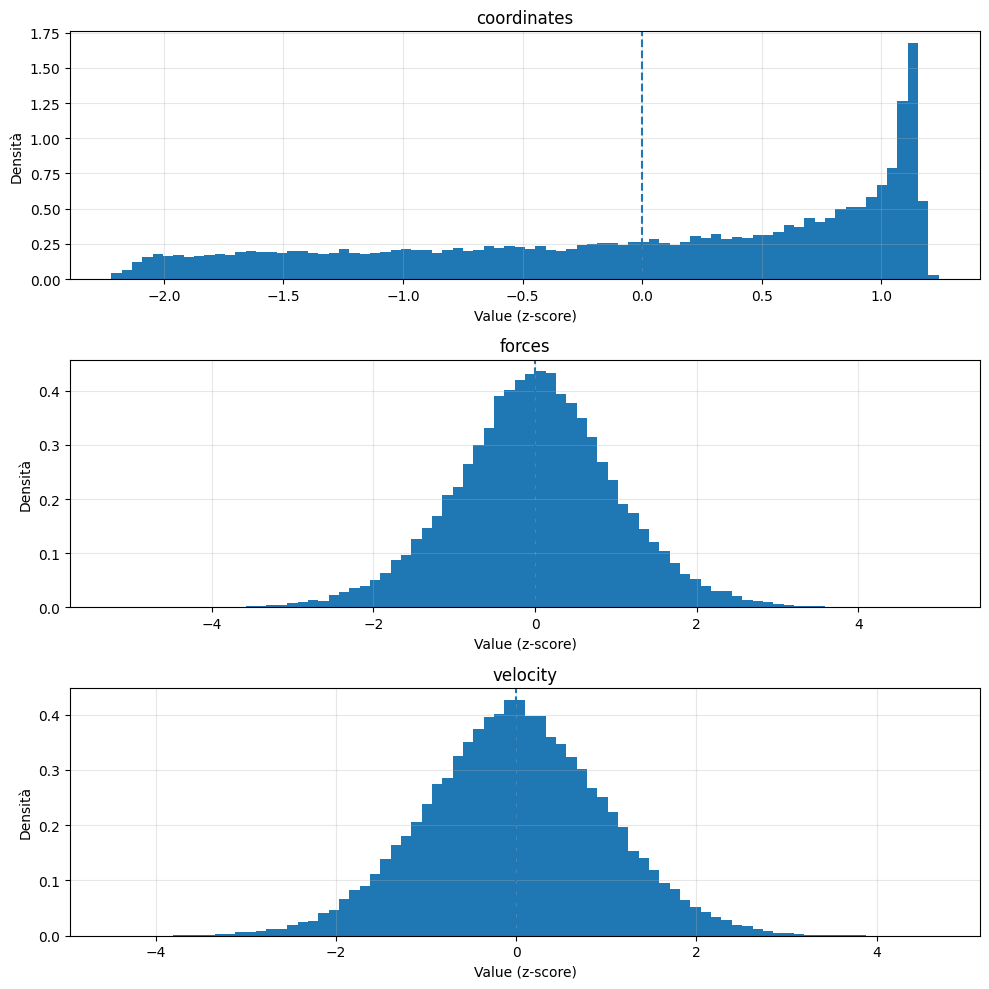

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = ["coordinates", "forces", "velocity"]

plt.figure(figsize=(10,10))

for i, d in enumerate(datasets, 1):
    df = pd.read_csv(f"processed_step1/{d}_scaled.csv")
    values = df.values.flatten()
    values = np.random.choice(values, size=50000, replace=False)

    plt.subplot(3, 1, i)
    plt.hist(values, bins=80, density=True)
    plt.axvline(0, linestyle="--")
    plt.title(f"{d}")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Densità")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Physical Interpretation of Distributions

### Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-Gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### Forces (Quasi-Gaussian)
The distribution of forces is **approximately Gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### Velocity (Gaussian)
The distribution of velocities is **Gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.

---

# Step 2 — Dataset Construction

This step transforms the preprocessed data into a format suitable for supervised time-series prediction.

The pipeline consists of:
1. **Dimensionality reduction**: compress each 414-dimensional dataset into 32 dimensions
2. **Feature concatenation**: combine the three reduced representations into a 96-dimensional feature vector
3. **Temporal split**: divide data chronologically into train/validation/test sets (70%/20%/10%)
4. **Windowing**: create supervised learning samples using sliding windows

---

## 11. Dimensionality Reduction Strategy

Each dataset contains 414 features (138 atoms × 3 coordinates). To make the problem tractable, we reduce each dataset to **32 dimensions**, achieving a compression ratio of ~13:1.

We use **autoencoders** for all three datasets. Initially, PCA was considered for forces and velocity (due to their approximately Gaussian distributions), but analysis showed that PCA with 32 components captured only ~23% (forces) and ~13% (velocity) of the variance. This indicated that the data has high intrinsic dimensionality with variance distributed across many independent directions.

Autoencoders, being non-linear, can learn more efficient compressed representations even when the data lacks a few dominant linear directions.

### Final Approach

| Dataset | Method | Rationale |
|---------|--------|-----------|
| Coordinates | Autoencoder | Non-linear structure due to molecular constraints |
| Forces | Autoencoder | High intrinsic dimensionality, PCA insufficient |
| Velocity | Autoencoder | High intrinsic dimensionality, PCA insufficient |

---

## 12. Autoencoder Architecture

The same architecture is used for all three datasets:

| Layer | Dimensions | Activation |
|-------|------------|------------|
| Input | 414 | — |
| Encoder Dense | 128 | ReLU |
| Encoder Dense | 64 | ReLU |
| **Bottleneck** | **32** | Linear |
| Decoder Dense | 64 | ReLU |
| Decoder Dense | 128 | ReLU |
| Output | 414 | Linear |

**Key design choices:**
- **Linear bottleneck and output**: essential for standardized data, which can have values outside [-1, +1]. Using sigmoid or tanh would clip these values.
- **Symmetric architecture**: balanced capacity for encoding and decoding.
- **MSE loss**: penalizes reconstruction errors proportionally to their magnitude.

---

## 13. Autoencoder Results

| Dataset | Original Dim | Latent Dim | Reconstruction MSE |
|---------|--------------|------------|-------------------|
| Coordinates | 414 | 32 | ~0.0001 |
| Forces | 414 | 32 | ~0.73 |
| Velocity | 414 | 32 | ~0.86 |

**Interpretation:**
- **Coordinates** achieve excellent reconstruction because atomic positions are highly constrained by molecular structure — atoms connected by bonds move together, creating strong correlations.
- **Forces and Velocity** have higher MSE because each atom's values are relatively independent, making compression more lossy. However, the autoencoders still capture the main patterns needed for prediction.

---

## 14. Feature Concatenation

The three latent representations are concatenated into a single feature vector per timestep:

| Component | Dimensions | Description |
|-----------|------------|-------------|
| Latent Coordinates | 32 | Compressed atomic positions |
| Latent Forces | 32 | Compressed atomic forces |
| Latent Velocity | 32 | Compressed atomic velocities |
| **Total** | **96** | Combined feature vector |

---

## 15. Train/Validation/Test Split

For time-series data, we must preserve temporal order to avoid data leakage. The split is performed **chronologically**:

| Set | Percentage | Samples | Timestep Range |
|-----|------------|---------|----------------|
| Train | 70% | 35,000 | 0 - 34,999 |
| Validation | 20% | 10,000 | 35,000 - 44,999 |
| Test | 10% | 5,001 | 45,000 - 50,000 |

This ensures that the model never sees future data during training.

---

## 16. Supervised Windowing

To predict future atomic positions, the model needs to learn from sequences of past observations. We use a **sliding window** approach:

- **Input**: W consecutive timesteps of features (coordinates + forces + velocity)
- **Output**: The coordinates at a future timestep (shift S steps ahead)

### Window Configurations

| Configuration | Input Width (W) | Shift (S) | Total Window | Input Shape | Target Shape |
|---------------|-----------------|-----------|--------------|-------------|--------------|
| Short-term | 10 | 10 | 20 | (10, 96) | (1, 32) |
| Medium-term | 30 | 10 | 40 | (30, 96) | (1, 32) |
| Long-term | 60 | 10 | 70 | (60, 96) | (1, 32) |

### Target Definition

The prediction target is the **latent coordinate representation** (32 dimensions) at timestep t+S. Forces and velocity are used as auxiliary input features but are not predicted directly.

### Shuffling Strategy

- **Training set**: Shuffled to improve gradient descent optimization
- **Validation/Test sets**: Not shuffled to preserve temporal order for realistic evaluation

---

## 17. Output Artifacts (Step 2)

All Step 2 artifacts are saved for reproducibility:

**Encoder Models** (`saved_models/`):
| File | Description |
|------|-------------|
| `encoder_coordinates.keras` | Trained encoder for coordinates |
| `encoder_forces.keras` | Trained encoder for forces |
| `encoder_velocity.keras` | Trained encoder for velocity |

**Processed Datasets** (`processed_step2/`):
| File | Description |
|------|-------------|
| `train_dataset.csv` | Training set (35,000 × 96) |
| `val_dataset.csv` | Validation set (10,000 × 96) |
| `test_dataset.csv` | Test set (5,001 × 96) |

---

## 18. Dataset Construction Summary

| Stage | Input | Output | Method |
|-------|-------|--------|--------|
| Scaling | Raw (414 features) | Scaled (414 features) | Z-score |
| Reduction | Scaled (414 features) | Latent (32 features) | Autoencoder |
| Concatenation | 3 × 32 features | 96 features | Horizontal concat |
| Split | 50,001 samples | Train/Val/Test | Chronological 70/20/10 |
| Windowing | Flat sequence | (W, 96) → (1, 32) | Sliding window |


DEBUG: CONTROLLO INTEGRITÀ E SCALING (STEP 1 -> STEP 2)

[1] Analisi file: coordinates_scaled.csv
   Shape: (50001, 414)
   ✓ Integrità dati: OK (Nessun NaN o Inf)
   ✓ Scaling Media:  PERFETTO (Max deviazione da 0: 1.1e-15)
   ✓ Scaling Std:    OK (Range std: [1.0000, 1.0000])

[2] Analisi file: forces_scaled.csv
   Shape: (50001, 414)
   ✓ Integrità dati: OK (Nessun NaN o Inf)
   ✓ Scaling Media:  PERFETTO (Max deviazione da 0: 8.6e-17)
   ✓ Scaling Std:    OK (Range std: [1.0000, 1.0000])

[3] Analisi file: velocity_scaled.csv
   Shape: (50001, 414)
   ✓ Integrità dati: OK (Nessun NaN o Inf)
   ✓ Scaling Media:  PERFETTO (Max deviazione da 0: 4.1e-17)
   ✓ Scaling Std:    OK (Range std: [1.0000, 1.0000])

Grafici salvati in: debug_check_step1.png
✅ VERDETTO: I DATI SONO PERFETTI. PUOI PROCEDERE CON L'AUTOENCODER.


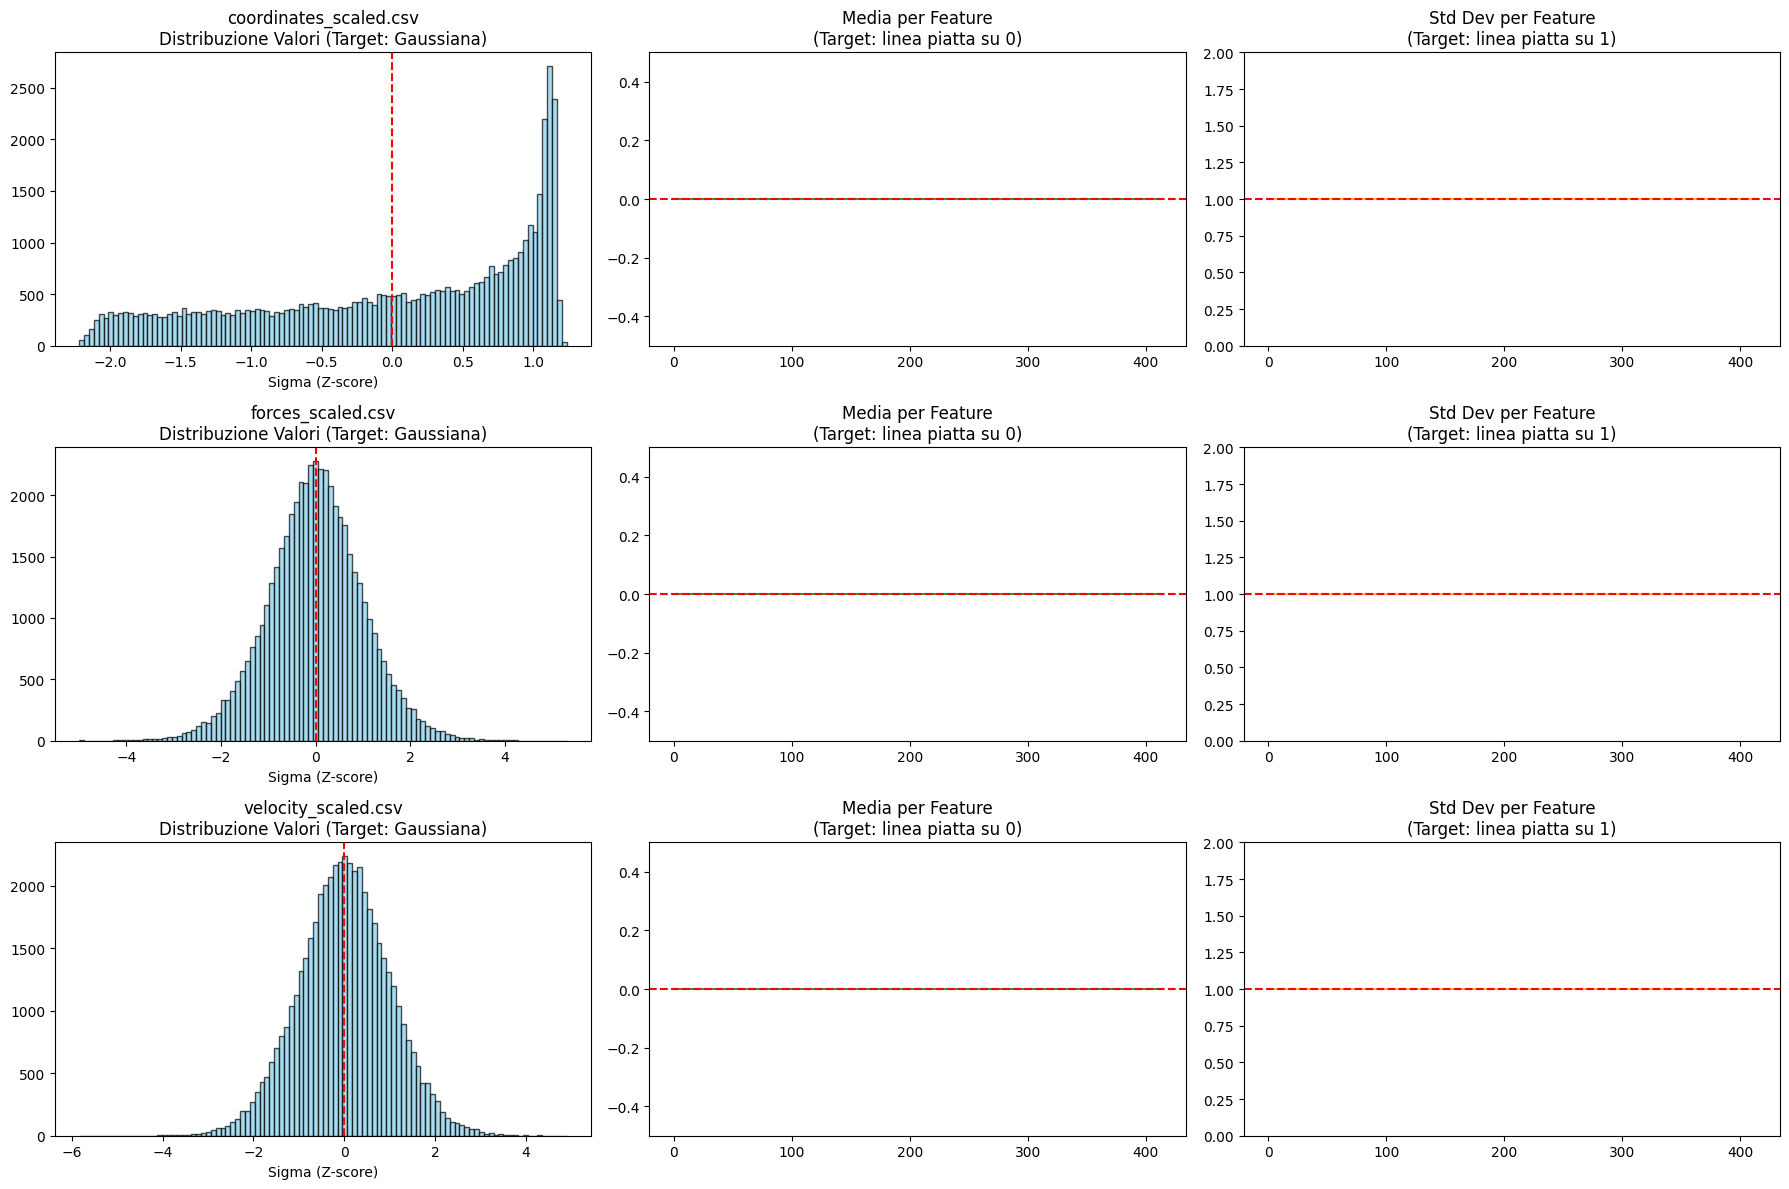

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Configurazione
INPUT_DIR = "processed_step1"
FILES_CHECK = ["coordinates_scaled.csv", "forces_scaled.csv", "velocity_scaled.csv"]

print("="*80)
print("DEBUG: CONTROLLO INTEGRITÀ E SCALING (STEP 1 -> STEP 2)")
print("="*80)

if not os.path.exists(INPUT_DIR):
    print(f"ERRORE CRITICO: La cartella {INPUT_DIR} non esiste!")
    exit()

all_good = True

fig, axes = plt.subplots(len(FILES_CHECK), 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

for i, filename in enumerate(FILES_CHECK):
    path = os.path.join(INPUT_DIR, filename)
    print(f"\n[{i+1}] Analisi file: {filename}")
    
    if not os.path.exists(path):
        print(f"   ROSSO: File non trovato!")
        all_good = False
        continue
        
    # Caricamento veloce
    df = pd.read_csv(path)
    data = df.values
    n_samples, n_features = data.shape
    
    print(f"   Shape: {data.shape}")
    
    # 1. Controllo NaN/Inf
    n_nans = np.isnan(data).sum()
    n_infs = np.isinf(data).sum()
    if n_nans == 0 and n_infs == 0:
        print("   ✓ Integrità dati: OK (Nessun NaN o Inf)")
    else:
        print(f"   ❌ ERRORE: Trovati {n_nans} NaN e {n_infs} Inf!")
        all_good = False

    # 2. Controllo Medie per Feature (Devono essere ~0)
    means = np.mean(data, axis=0)
    mean_of_means = np.mean(np.abs(means))
    max_mean_dev = np.max(np.abs(means))
    
    if max_mean_dev < 1e-5: # Tolleranza stretta
        print(f"   ✓ Scaling Media:  PERFETTO (Max deviazione da 0: {max_mean_dev:.1e})")
    elif max_mean_dev < 1e-2:
        print(f"   ✓ Scaling Media:  ACCETTABILE (Max deviazione da 0: {max_mean_dev:.1e})")
    else:
        print(f"   ❌ ERRORE SCALING: Le medie non sono 0! (Max dev: {max_mean_dev:.4f})")
        print("      Hai usato 'global' invece di 'per_feature'?")
        all_good = False

    # 3. Controllo Std per Feature (Devono essere ~1)
    stds = np.std(data, axis=0)
    mean_of_stds = np.mean(stds)
    min_std = np.min(stds)
    max_std = np.max(stds)
    
    # Controllo se le std sono vicine a 1
    if abs(mean_of_stds - 1.0) < 1e-2 and min_std > 0.9 and max_std < 1.1:
        print(f"   ✓ Scaling Std:    OK (Range std: [{min_std:.4f}, {max_std:.4f}])")
    else:
        # Se una feature era costante (tutti zeri), la std sarà 0. È un caso limite.
        zero_std_cols = np.sum(stds < 1e-6)
        if zero_std_cols > 0:
            print(f"   ⚠ ATTENZIONE: {zero_std_cols} feature hanno Std=0 (erano costanti).")
        else:
            print(f"   ❌ ERRORE SCALING: Le Std non sono 1! (Range: [{min_std:.4f}, {max_std:.4f}])")
            all_good = False

    # === GRAFICI DI DIAGNOSTICA ===
    
    # Plot 1: Istogramma dei valori (dovrebbe essere una Gaussiana centrata in 0)
    flat_sample = data.flatten()
    if len(flat_sample) > 50000: flat_sample = np.random.choice(flat_sample, 50000)
    
    axes[i, 0].hist(flat_sample, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f"{filename}\nDistribuzione Valori (Target: Gaussiana)")
    axes[i, 0].set_xlabel("Sigma (Z-score)")
    axes[i, 0].axvline(0, color='red', linestyle='--')
    
    # Plot 2: Medie per colonna (dovrebbe essere una linea piatta su 0)
    axes[i, 1].plot(means, color='green', alpha=0.8)
    axes[i, 1].set_title(f"Media per Feature\n(Target: linea piatta su 0)")
    axes[i, 1].set_ylim(-0.5, 0.5) # Zoom intorno a 0
    axes[i, 1].axhline(0, color='red', linestyle='--')
    
    # Plot 3: Std per colonna (dovrebbe essere una linea piatta su 1)
    axes[i, 2].plot(stds, color='orange', alpha=0.8)
    axes[i, 2].set_title(f"Std Dev per Feature\n(Target: linea piatta su 1)")
    axes[i, 2].set_ylim(0, 2.0) # Zoom intorno a 1
    axes[i, 2].axhline(1, color='red', linestyle='--')

# Salvataggio grafico
out_img = "debug_check_step1.png"
plt.tight_layout()
plt.savefig(out_img)
print(f"\nGrafici salvati in: {out_img}")

print("="*80)
if all_good:
    print("✅ VERDETTO: I DATI SONO PERFETTI. PUOI PROCEDERE CON L'AUTOENCODER.")
else:
    print("❌ VERDETTO: CI SONO PROBLEMI. NON LANCIARE L'ADDESTRAMENTO.")
print("="*80)

In [16]:
"""
================================================================================
AUTOENCODER: ONLY COORDINATES (CLEAN VERSION)
================================================================================
Obiettivo: Comprimere solo la geometria (che è il dato più affidabile).
Ignoriamo forze e velocità per eliminare il rumore.
"""

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# ================= CONFIGURAZIONE =================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_PATH = "processed_step1"
OUT_PATH = "processed_step2_coords_only"  # Nuova cartella per non mischiare
MODEL_PATH = "saved_models_coords"
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

# Parametri
INPUT_DIM = 414          # Solo coordinate
LATENT_DIM = 32          # Comprimiamo a 32 numeri puri
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE = 15

# Split (Temporale)
TRAIN_SIZE = 35000
VAL_SIZE = 10000

print("=" * 70)
print("TRAINING AUTOENCODER - COORDINATES ONLY")
print("=" * 70)

# ================= 1. CARICAMENTO DATI =================
print("Loading Coordinates...")
df = pd.read_csv(os.path.join(INPUT_PATH, "coordinates_scaled.csv"))
data = df.values.astype(np.float32)

print(f"Data shape: {data.shape}")

# Split temporale
train_data = data[:TRAIN_SIZE]
val_data = data[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]
test_data = data[TRAIN_SIZE + VAL_SIZE :]

# ================= 2. ARCHITETTURA AUTOENCODER =================
def build_autoencoder(input_dim, latent_dim):
    inp = layers.Input(shape=(input_dim,))
    
    # Encoder
    e = layers.Dense(256)(inp)
    e = layers.BatchNormalization()(e)
    e = layers.ReLU()(e)
    e = layers.Dropout(0.1)(e)
    
    e = layers.Dense(128)(e)
    e = layers.BatchNormalization()(e)
    e = layers.ReLU()(e)
    
    e = layers.Dense(64)(e)
    e = layers.BatchNormalization()(e)
    e = layers.ReLU()(e)
    
    # Bottleneck (Lineare)
    latent = layers.Dense(latent_dim, activation="linear", name="bottleneck")(e)
    
    # Decoder
    d = layers.Dense(64)(latent)
    d = layers.BatchNormalization()(d)
    d = layers.ReLU()(d)
    
    d = layers.Dense(128)(d)
    d = layers.BatchNormalization()(d)
    d = layers.ReLU()(d)
    
    d = layers.Dense(256)(d)
    d = layers.BatchNormalization()(d)
    d = layers.ReLU()(d)
    
    out = layers.Dense(input_dim, activation="linear")(d)
    
    ae = models.Model(inp, out)
    enc = models.Model(inp, latent)
    
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc

ae, enc = build_autoencoder(INPUT_DIM, LATENT_DIM)

# ================= 3. TRAINING =================
print("\nInizio Training...")
callbacks_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

history = ae.fit(
    train_data, train_data,
    validation_data=(val_data, val_data),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

# ================= 4. SALVATAGGIO & CREAZIONE DATASET LATENTE =================
print("\nGenerazione Spazio Latente...")
latent_all = enc.predict(data, verbose=0)

# Creazione DataFrame Latente
cols = [f"Latent_{i}" for i in range(LATENT_DIM)]
df_latent = pd.DataFrame(latent_all, columns=cols)

# Salvataggio Dataset Divisi per Step 3
train_df = df_latent.iloc[:TRAIN_SIZE]
val_df = df_latent.iloc[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]
test_df = df_latent.iloc[TRAIN_SIZE + VAL_SIZE :]

train_df.to_csv(os.path.join(OUT_PATH, "train_dataset.csv"), index=False)
val_df.to_csv(os.path.join(OUT_PATH, "val_dataset.csv"), index=False)
test_df.to_csv(os.path.join(OUT_PATH, "test_dataset.csv"), index=False)

print(f"\n✓ Dataset salvati in: {OUT_PATH}")
print(f"✓ Dimensioni finali input per CNN: {LATENT_DIM} features")

# Test MSE finale
mse = ae.evaluate(test_data, test_data, verbose=0)
print(f"\nFINAL TEST MSE (Reconstruction): {mse:.6f}")

ae.save(os.path.join(MODEL_PATH, "autoencoder.keras"))
enc.save(os.path.join(MODEL_PATH, "encoder.keras"))

print("✓ Autoencoder salvato")
print("✓ Encoder salvato")

TRAINING AUTOENCODER - COORDINATES ONLY
Loading Coordinates...
Data shape: (50001, 414)

Inizio Training...
Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0216 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0068 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0047 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0036 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0031 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 6/100
545/547 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0027 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0019 - val_loss: 0.0886 - learn

In [15]:
"""
================================================================================
STEP 3 — CNN Parametrica (DELTA / RESIDUAL LEARNING) con Windowing + Shift + Tuning
Input:  latenti da Autoencoder (train/val/test csv)
Output: tabella risultati + best models + plots .jpeg 300dpi (+ rollout)

Idea (DELTA):
- X: finestra di lunghezza W su z(t) (latenti)
- target: Δz = z(t+shift) - z(t)   (residual)
- ricostruzione assoluta (one-step):  ẑ(t+shift) = z(t) + Δẑ

Baselines (su Δz):
- ZERO:   Δẑ = 0
- MEAN:   Δẑ = mean(Δz_train)
(Nota: PERSIST sul delta coincide con ZERO)
================================================================================
"""

import os
import random
import json
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# =========================
# 0) REPRODUCIBILITY
# =========================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism(True)
except Exception:
    pass

# =========================
# 1) PATHS
# =========================
INPUT_PATH = "processed_step2_coords_only"   # latenti: train/val/test csv
OUT_PATH = "results_step3_cnn_delta_latent"
MODELS_PATH = os.path.join(OUT_PATH, "saved_models")
PLOTS_PATH  = os.path.join(OUT_PATH, "plots")
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,  exist_ok=True)

# =========================
# 2) LOAD LATENT DATA
# =========================
def load_split(name: str) -> np.ndarray:
    df = pd.read_csv(os.path.join(INPUT_PATH, name))
    return df.values.astype(np.float32)

train_seq = load_split("train_dataset.csv")  # (T_train, F)
val_seq   = load_split("val_dataset.csv")
test_seq  = load_split("test_dataset.csv")

LATENT_DIM = train_seq.shape[1]
print("Latent dim:", LATENT_DIM)
print("Train/Val/Test:", train_seq.shape, val_seq.shape, test_seq.shape)

# =========================
# 3) WINDOWING + SHIFT (DELTA TARGET)
# =========================
def make_windows_delta(series: np.ndarray, input_width: int, shift: int):
    """
    series: (T, F)
    X: (N, input_width, F)  -> z history
    z_last: (N, F)          -> z(t) = last element of window
    y_delta: (N, F)         -> z(t+shift) - z(t)
    """
    T, F = series.shape
    X, z_last, y_delta = [], [], []

    last_start = T - (input_width + shift)  # i in [0, last_start-1]
    for i in range(last_start):
        x_win = series[i : i + input_width]
        z_t   = series[i + input_width - 1]
        z_fut = series[i + input_width - 1 + shift]
        X.append(x_win)
        z_last.append(z_t)
        y_delta.append(z_fut - z_t)

    return (
        np.array(X, dtype=np.float32),
        np.array(z_last, dtype=np.float32),
        np.array(y_delta, dtype=np.float32),
    )

# =========================
# 4) METRICS + BASELINES
# =========================
def mse(a, b) -> float:
    return float(np.mean((a - b) ** 2))

def mae(a, b) -> float:
    return float(np.mean(np.abs(a - b)))

def compute_delta_baselines(y_delta_test: np.ndarray, y_delta_train: np.ndarray):
    """
    Baselines on delta:
    - ZERO: predict 0
    - MEAN: predict mean delta over train
    """
    zero = np.zeros_like(y_delta_test)
    mean_delta = np.mean(y_delta_train, axis=0, keepdims=True)
    mean_pred = np.repeat(mean_delta, repeats=y_delta_test.shape[0], axis=0)

    zero_mse = mse(y_delta_test, zero)
    zero_mae = mae(y_delta_test, zero)

    mean_mse_ = mse(y_delta_test, mean_pred)
    mean_mae_ = mae(y_delta_test, mean_pred)

    return zero_mse, zero_mae, mean_mse_, mean_mae_

# =========================
# 5) MODEL BUILDER (PARAMETRICO)
# =========================
def build_cnn_delta(input_width: int, n_features: int, cfg: dict) -> tf.keras.Model:
    inp = layers.Input(shape=(input_width, n_features))
    x = inp

    for (filters, kernel) in cfg["conv_blocks"]:
        x = layers.Conv1D(filters=filters, kernel_size=kernel, padding="causal", activation="linear")(x)
        if cfg.get("batchnorm", True):
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        if cfg.get("pool", None) == "max":
            x = layers.MaxPooling1D(pool_size=2)(x)

        x = layers.Dropout(cfg["dropout"])(x)

    if cfg.get("global_pool", "gap") == "gap":
        x = layers.GlobalAveragePooling1D()(x)
    else:
        x = layers.Flatten()(x)

    x = layers.Dense(cfg["dense_units"], activation="relu")(x)
    x = layers.Dropout(cfg["dropout"])(x)

    out = layers.Dense(n_features, activation="linear")(x)  # predicts Δz (pos/neg)

    model = models.Model(inp, out, name=cfg["name"])
    opt = tf.keras.optimizers.Adam(learning_rate=cfg["lr"], clipnorm=1.0)
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model

# =========================
# 6) CONFIG GRID (TUNING)
# =========================
CNN_CONFIGS = [
    {
        "name": "cnn_small",
        "conv_blocks": [(32, 3), (64, 3)],
        "dropout": 0.10,
        "dense_units": 64,
        "lr": 1e-3,
        "batchnorm": True,
        "pool": "max",
        "global_pool": "gap",
    },
    {
        "name": "cnn_medium",
        "conv_blocks": [(64, 5), (128, 3)],
        "dropout": 0.20,
        "dense_units": 128,
        "lr": 1e-3,
        "batchnorm": True,
        "pool": "max",
        "global_pool": "gap",
    },
    {
        "name": "cnn_large",
        "conv_blocks": [(128, 5), (256, 3)],
        "dropout": 0.30,
        "dense_units": 256,
        "lr": 8e-4,
        "batchnorm": True,
        "pool": "max",
        "global_pool": "gap",
    },
]

WINDOWS = [10, 30, 60]
SHIFTS  = [1, 5, 10]

BATCH_SIZE = 64
MAX_EPOCHS = 150
PATIENCE = 20

# =========================
# 7) PLOTS (JPEG 300dpi)
# =========================
def save_loss_plot(hist, out_file, title):
    plt.figure(figsize=(9, 5))
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("mse")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, format="jpeg", bbox_inches="tight")
    plt.close()

def save_rollout_plot(z_true, z_pred, feat_idxs, out_file, title, max_steps=200):
    """
    z_true/z_pred: (T, F)
    """
    steps = np.arange(min(max_steps, z_true.shape[0]))
    feat_idxs = [i for i in feat_idxs if i < z_true.shape[1]]
    if len(feat_idxs) == 0:
        return

    plt.figure(figsize=(12, 3 * len(feat_idxs)))
    for k, idx in enumerate(feat_idxs, start=1):
        plt.subplot(len(feat_idxs), 1, k)
        plt.plot(steps, z_true[:len(steps), idx], label="true", linewidth=1.5, alpha=0.7)
        plt.plot(steps, z_pred[:len(steps), idx], label="pred", linestyle="--", linewidth=1.5)
        plt.title(f"{title} — feature {idx}")
        plt.grid(True, alpha=0.3)
        plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, format="jpeg", bbox_inches="tight")
    plt.close()

# =========================
# 8) ROLLOUT (multi-step) in latent
# =========================
def rollout_latent(model, series: np.ndarray, input_width: int, shift: int, rollout_steps: int):
    """
    Rollout autoregressivo:
    - parte da una finestra iniziale reale
    - a ogni step predice Δz per horizon=shift, costruisce z_next = z_last + Δz_pred
    - poi fa scorrere la finestra aggiungendo z_next

    Nota: questo rollout è "step-by-step" anche se shift>1 (approssimazione).
    Per shift>1 resta comunque utile per vedere drift/stabilità.
    """
    if series.shape[0] < input_width + 2:
        raise ValueError("Serie troppo corta per il rollout con questa window.")

    # start window from real data
    window = series[:input_width].copy()  # (W, F)
    preds = []
    trues = []

    # vero prossimo: useremo la serie reale avanzando di 1 (per confronto visivo)
    # (rollout_steps non deve superare i punti disponibili)
    max_possible = min(rollout_steps, series.shape[0] - input_width - 1)

    for t in range(max_possible):
        x = window[None, :, :]  # (1, W, F)
        dz = model.predict(x, verbose=0)[0]  # (F,)
        z_last = window[-1]
        z_next = z_last + dz  # one-step constructed

        preds.append(z_next)
        trues.append(series[input_width + t])  # target reale (allineamento a 1 step)

        # slide window
        window = np.vstack([window[1:], z_next[None, :]])

    return np.array(trues, dtype=np.float32), np.array(preds, dtype=np.float32)

# =========================
# 9) TRAIN + EVAL LOOP
# =========================
results = []
best_overall = {"test_delta_mse": float("inf"), "tag": None}

print("=" * 80)
print("CNN DELTA SHIFT TUNING: configs × windows × shifts (+ baselines, + rollout)")
print(f"Configs: {len(CNN_CONFIGS)}, Windows: {WINDOWS}, Shifts: {SHIFTS}")
print("=" * 80)

for cfg in CNN_CONFIGS:
    for w in WINDOWS:
        for s in SHIFTS:
            tag = f"{cfg['name']}_W{w}_S{s}"
            print("\n" + "-" * 80)
            print("RUN:", tag)

            # build delta datasets
            X_train, zt_train, ydel_train = make_windows_delta(train_seq, w, s)
            X_val,   zt_val,   ydel_val   = make_windows_delta(val_seq,   w, s)
            X_test,  zt_test,  ydel_test  = make_windows_delta(test_seq,  w, s)

            print("Shapes:", X_train.shape, ydel_train.shape, "|", X_val.shape, "|", X_test.shape)

            # baselines on delta
            base0_mse, base0_mae, basem_mse, basem_mae = compute_delta_baselines(ydel_test, ydel_train)

            model = build_cnn_delta(input_width=w, n_features=LATENT_DIM, cfg=cfg)

            cb = [
                callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                        restore_best_weights=True, verbose=1),
                callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, verbose=1),
            ]

            t0 = time.time()
            hist = model.fit(
                X_train, ydel_train,
                validation_data=(X_val, ydel_val),
                epochs=MAX_EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=cb,
                verbose=1
            )
            train_time = time.time() - t0

            # eval on delta
            test_mse, test_mae = model.evaluate(X_test, ydel_test, verbose=0)

            best_epoch = int(np.argmin(hist.history["val_loss"]) + 1)
            best_val = float(np.min(hist.history["val_loss"]))

            # improvements vs baselines (delta)
            eps = 1e-12
            imp_vs_zero = 100.0 * (base0_mse - float(test_mse)) / (base0_mse + eps)
            imp_vs_mean = 100.0 * (basem_mse - float(test_mse)) / (basem_mse + eps)

            print(f"Best epoch: {best_epoch} | best val mse: {best_val:.6f}")
            print(f"TEST  Δmse: {test_mse:.6f} | Δmae: {test_mae:.6f} | time: {train_time:.1f}s")
            print(f"BASELINE ZERO  Δmse: {base0_mse:.6f} | Δmae: {base0_mae:.6f}")
            print(f"BASELINE MEAN  Δmse: {basem_mse:.6f} | Δmae: {basem_mae:.6f}")
            print(f"Improvement vs ZERO (ΔMSE): {imp_vs_zero:.2f}%")
            print(f"Improvement vs MEAN (ΔMSE): {imp_vs_mean:.2f}%")

            # save plot + model
            plot_file = os.path.join(PLOTS_PATH, f"{tag}_loss.jpeg")
            save_loss_plot(hist, plot_file, title=f"{tag} — delta training curve")

            model_file = os.path.join(MODELS_PATH, f"{tag}.keras")
            model.save(model_file)

            # one-step absolute reconstruction (from test windows)
            # ẑ(t+shift) = z(t) + Δẑ
            pred_del = model.predict(X_test, verbose=0)
            z_abs_pred = zt_test + pred_del
            z_abs_true = zt_test + ydel_test  # equals real z(t+shift)

            abs_mse_1step = mse(z_abs_true, z_abs_pred)
            abs_mae_1step = mae(z_abs_true, z_abs_pred)

            # rollout (optional but very useful for report)
            rollout_steps = 300
            try:
                z_true_roll, z_pred_roll = rollout_latent(model, test_seq, w, s, rollout_steps=rollout_steps)
                rollout_mse = mse(z_true_roll, z_pred_roll)
                rollout_mae = mae(z_true_roll, z_pred_roll)

                roll_plot = os.path.join(PLOTS_PATH, f"{tag}_rollout.jpeg")
                save_rollout_plot(
                    z_true_roll, z_pred_roll,
                    feat_idxs=[0, 5, 15],  # cambia pure questi indici
                    out_file=roll_plot,
                    title=f"{tag} rollout (latent)",
                    max_steps=200
                )
            except Exception as e:
                rollout_mse = np.nan
                rollout_mae = np.nan
                roll_plot = ""
                print("Rollout skipped:", str(e))

            # store result row
            results.append({
                "tag": tag,
                "config": cfg["name"],
                "input_width": w,
                "shift": s,
                "latent_dim": LATENT_DIM,

                "best_epoch": best_epoch,
                "best_val_delta_mse": best_val,

                "test_delta_mse": float(test_mse),
                "test_delta_mae": float(test_mae),

                "baseline_zero_delta_mse": float(base0_mse),
                "baseline_zero_delta_mae": float(base0_mae),
                "baseline_mean_delta_mse": float(basem_mse),
                "baseline_mean_delta_mae": float(basem_mae),

                "improve_vs_zero_%": float(imp_vs_zero),
                "improve_vs_mean_%": float(imp_vs_mean),

                "abs_1step_mse": float(abs_mse_1step),
                "abs_1step_mae": float(abs_mae_1step),

                "rollout_mse": float(rollout_mse) if np.isfinite(rollout_mse) else np.nan,
                "rollout_mae": float(rollout_mae) if np.isfinite(rollout_mae) else np.nan,

                "train_time_sec": float(train_time),
                "model_path": model_file,
                "plot_loss_path": plot_file,
                "plot_rollout_path": roll_plot,
                "cfg_json": json.dumps(cfg),
            })

            if float(test_mse) < best_overall["test_delta_mse"]:
                best_overall = {"test_delta_mse": float(test_mse), "tag": tag}

# =========================
# 10) SAVE SUMMARY TABLES
# =========================
df_res = pd.DataFrame(results)

# migliori per delta test mse (primary)
df_by_test = df_res.sort_values(["test_delta_mse", "test_delta_mae"])
out_test = os.path.join(OUT_PATH, "cnn_delta_tuning_by_test.csv")
df_by_test.to_csv(out_test, index=False)

# migliori per miglioramento vs ZERO (delta)
df_by_imp = df_res.sort_values(["improve_vs_zero_%", "test_delta_mse"], ascending=[False, True])
out_imp = os.path.join(OUT_PATH, "cnn_delta_tuning_by_improve.csv")
df_by_imp.to_csv(out_imp, index=False)

print("\n" + "=" * 80)
print("DONE.")
print("Best overall by ΔTEST MSE:", best_overall)
print("Saved:", out_test)
print("Saved:", out_imp)
print("Plots (.jpeg 300dpi) in:", PLOTS_PATH)
print("=" * 80)


Latent dim: 32
Train/Val/Test: (35000, 32) (10000, 32) (5001, 32)
CNN DELTA SHIFT TUNING: configs × windows × shifts (+ baselines, + rollout)
Configs: 3, Windows: [10, 30, 60], Shifts: [1, 5, 10]

--------------------------------------------------------------------------------
RUN: cnn_small_W10_S1
Shapes: (34989, 10, 32) (34989, 32) | (9989, 10, 32) | (4990, 10, 32)
Epoch 1/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0061 - mae: 0.0218 - val_loss: 2.2887e-06 - val_mae: 5.9334e-04 - learning_rate: 0.0010
Epoch 2/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.6447e-05 - mae: 8.6653e-04 - val_loss: 2.2541e-06 - val_mae: 5.2256e-04 - learning_rate: 0.0010
Epoch 3/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.4694e-06 - mae: 5.0302e-04 - val_loss: 2.2475e-06 - val_mae: 5.0514e-04 - learning_rate: 0.0010
Epoch 4/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.4832e-06 - mae: 3.8071e-04 - val_loss: 2.2565e-06 - val_mae: 4.9778e-04 - learning_rate: 0.0010
Ep

KeyboardInterrupt: 

In [24]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import Model
from tensorflow.keras.models import load_model

# ================= CONFIG =================
ENCODER_PATH = "saved_models_coords/encoder.keras"
COORDS_PATH  = "processed_step1/coordinates_scaled.csv"

OUTDIR_MODELS = "saved_models_cnn_shift50"
os.makedirs(OUTDIR_MODELS, exist_ok=True)

LATENT_DIM = 32
WINDOW     = 60    
SHIFT      = 50

TRAIN_SIZE = 35000
VAL_SIZE   = 10000

BATCH_SIZE = 64
MAX_EPOCHS = 150
PATIENCE   = 15
LR         = 1e-3

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================= LOAD DATA + ENCODER =================
encoder = load_model(ENCODER_PATH)

coords = pd.read_csv(COORDS_PATH).values.astype(np.float32)
latent = encoder.predict(coords, verbose=0)  # (T, 32)

print("coords:", coords.shape, "latent:", latent.shape)

# ================= WINDOWING (Δ-latent) =================
def make_windows_delta(lat, w, s):
    """
    X: (N, w, D)  finestre di latent
    Y_delta: (N, D) delta = z(t+w+s-1) - z(t+w-1)
    """
    X, Y = [], []
    T = len(lat)
    last_in_idx = w - 1
    target_offset = w + s - 1  # indice target relativo a inizio finestra

    for i in range(T - (w + s)):
        z_last   = lat[i + last_in_idx]
        z_target = lat[i + target_offset]
        X.append(lat[i:i+w])
        Y.append(z_target - z_last)

    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.float32)

X, Y_delta = make_windows_delta(latent, WINDOW, SHIFT)
print("X:", X.shape, "Y_delta:", Y_delta.shape)

# Split coerente col tuo schema (temporal split)
X_train = X[:TRAIN_SIZE]
Y_train = Y_delta[:TRAIN_SIZE]

X_val   = X[TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE]
Y_val   = Y_delta[TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE]

X_test  = X[TRAIN_SIZE+VAL_SIZE:]
Y_test  = Y_delta[TRAIN_SIZE+VAL_SIZE:]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

# ================= MODEL CNN Δ =================
def build_cnn_delta(w, d, latent_dim=32, lr=1e-3, dropout=0.2, filters=(64,128), k=3, dense=128):
    inp = layers.Input(shape=(w, d))

    x = layers.Conv1D(filters[0], k, padding="causal", activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters[1], k, padding="causal", activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(latent_dim, activation="linear")(x)  # Δz
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return m

cnn = build_cnn_delta(WINDOW, LATENT_DIM, latent_dim=LATENT_DIM, lr=LR)

cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
]

hist = cnn.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

save_path = os.path.join(OUTDIR_MODELS, f"cnn_delta_W{WINDOW}_S{SHIFT}.keras")
cnn.save(save_path)
print("Saved:", save_path)


coords: (50001, 414) latent: (50001, 32)
X: (49891, 60, 32) Y_delta: (49891, 32)
Train/Val/Test: (35000, 60, 32) (10000, 60, 32) (4891, 60, 32)
Epoch 1/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 5.2238e-04 - mae: 0.0074 - val_loss: 1.7997e-04 - val_mae: 0.0106 - learning_rate: 0.0010
Epoch 2/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2.4850e-05 - mae: 0.0035 - val_loss: 1.5768e-04 - val_mae: 0.0096 - learning_rate: 0.0010
Epoch 3/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2.0501e-05 - mae: 0.0032 - val_loss: 1.6973e-04 - val_mae: 0.0098 - learning_rate: 0.0010
Epoch 4/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1.7610e-05 - mae: 0.0030 - val_loss: 2.3832e-04 - val_mae: 0.0117 - learning_rate: 0.0010
Epoch 5/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.5418e-05 - mae: 0.0028 - val_loss: 1.7110e-04 - val_mae: 0.0100 - learning_rate: 0.0010
Epoch 6/150
544/547 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4000e-05 - mae: 0.0027
Epoch 6:

In [25]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# ================= CONFIG =================
ENCODER_PATH = "saved_models_coords/encoder.keras"
DECODER_PATH = "saved_models_coords/decoder.keras"
CNN_PATH     = "saved_models_cnn_shift50/cnn_delta_W60_S50.keras"  # <-- quello salvato sopra
COORDS_PATH  = "processed_step1/coordinates_scaled.csv"

LATENT_DIM = 32
WINDOW     = 60
SHIFT      = 50
TRAIN_SIZE = 35000
VAL_SIZE   = 10000

# ================= LOAD =================
encoder = load_model(ENCODER_PATH)
decoder = load_model(DECODER_PATH)
cnn     = load_model(CNN_PATH)

coords = pd.read_csv(COORDS_PATH).values.astype(np.float32)
latent = encoder.predict(coords, verbose=0)

def make_windows_targets(lat, w, s):
    """
    Ritorna:
    X: (N,w,D)
    z_last: (N,D) = z(t+w-1)
    z_true: (N,D) = z(t+w+s-1)
    """
    X, z_last, z_true = [], [], []
    T = len(lat)
    last_in_idx = w - 1
    target_offset = w + s - 1
    for i in range(T - (w + s)):
        X.append(lat[i:i+w])
        z_last.append(lat[i + last_in_idx])
        z_true.append(lat[i + target_offset])
    return (np.asarray(X, dtype=np.float32),
            np.asarray(z_last, dtype=np.float32),
            np.asarray(z_true, dtype=np.float32))

X, z_last, z_true = make_windows_targets(latent, WINDOW, SHIFT)

# test split coerente
X_test     = X[TRAIN_SIZE + VAL_SIZE:]
z_last_t   = z_last[TRAIN_SIZE + VAL_SIZE:]
z_true_t   = z_true[TRAIN_SIZE + VAL_SIZE:]

# ================= PREDICT =================
delta_pred = cnn.predict(X_test, verbose=0)
z_pred     = z_last_t + delta_pred

# ================= METRICS in LATENT =================
mse_lat_cnn  = np.mean((z_pred - z_true_t)**2)
mae_lat_cnn  = np.mean(np.abs(z_pred - z_true_t))

# baseline NO-CHANGE: z_pred = z_last
mse_lat_base = np.mean((z_last_t - z_true_t)**2)
mae_lat_base = np.mean(np.abs(z_last_t - z_true_t))

print("="*60)
print("LATENT-SPACE EVALUATION")
print("="*60)
print(f"WINDOW={WINDOW} SHIFT={SHIFT} | N={len(X_test)}")
print(f"CNN    MSE: {mse_lat_cnn:.6f} | MAE: {mae_lat_cnn:.6f}")
print(f"BASE   MSE: {mse_lat_base:.6f} | MAE: {mae_lat_base:.6f}")
print(f"Improvement vs BASE (MSE): {(mse_lat_base - mse_lat_cnn)/mse_lat_base*100:.2f}%")
print(f"Improvement vs BASE (MAE): {(mae_lat_base - mae_lat_cnn)/mae_lat_base*100:.2f}%")

# ================= DECODE to COORDINATES =================
coords_pred = decoder.predict(z_pred, verbose=0)
coords_base = decoder.predict(z_last_t, verbose=0)
coords_true = decoder.predict(z_true_t, verbose=0)  # confronto coerente decoder vs decoder

mse_xyz_cnn  = np.mean((coords_pred - coords_true)**2)
mae_xyz_cnn  = np.mean(np.abs(coords_pred - coords_true))

mse_xyz_base = np.mean((coords_base - coords_true)**2)
mae_xyz_base = np.mean(np.abs(coords_base - coords_true))

print("\n" + "="*60)
print("COORDINATE-SPACE EVALUATION (decoded)")
print("="*60)
print(f"CNN    MSE: {mse_xyz_cnn:.6f} | MAE: {mae_xyz_cnn:.6f}")
print(f"BASE   MSE: {mse_xyz_base:.6f} | MAE: {mae_xyz_base:.6f}")
print(f"Improvement vs BASE (MSE): {(mse_xyz_base - mse_xyz_cnn)/mse_xyz_base*100:.2f}%")
print(f"Improvement vs BASE (MAE): {(mae_xyz_base - mae_xyz_cnn)/mae_xyz_base*100:.2f}%")


LATENT-SPACE EVALUATION
WINDOW=60 SHIFT=50 | N=4891
CNN    MSE: 0.000473 | MAE: 0.018012
BASE   MSE: 0.000742 | MAE: 0.022234
Improvement vs BASE (MSE): 36.21%
Improvement vs BASE (MAE): 18.99%

COORDINATE-SPACE EVALUATION (decoded)
CNN    MSE: 0.000013 | MAE: 0.003358
BASE   MSE: 0.000033 | MAE: 0.005674
Improvement vs BASE (MSE): 58.80%
Improvement vs BASE (MAE): 40.81%


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras import models

# =========================
# CONFIG
# =========================
ENCODER_PATH = "saved_models_coords/encoder.keras"
DECODER_PATH = "saved_models_coords/decoder.keras"
COORDS_PATH  = "processed_step1/coordinates_scaled.csv"

# Metti qui i path dei BEST model per ciascuno shift
CNN_MODELS = {
    10: "results_step3_cnn_delta_latent/saved_models/cnn_small_W10_S10.keras",   # <-- cambia col tuo path reale
    50: "saved_models_cnn_shift50/cnn_delta_W60_S50.keras",   # <-- cambia col tuo path reale
}

WINDOWS = {
    10: 10,   # tipico: W10 per shift 10
    50: 60,   # tipico: W60 per shift 50 (come hai testato)
}

TRAIN_SIZE = 35000
VAL_SIZE   = 10000

# =========================
# LOAD
# =========================
encoder = models.load_model(ENCODER_PATH)
decoder = models.load_model(DECODER_PATH)
coords  = pd.read_csv(COORDS_PATH).values.astype(np.float32)

latent = encoder.predict(coords, verbose=0)  # (T, latent_dim)

# =========================
# HELPERS
# =========================
def make_windows(x, w, s):
    X, Y = [], []
    # target = x[t + w + s - 1]
    for t in range(len(x) - w - s):
        X.append(x[t:t+w])
        Y.append(x[t+w+s-1])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

def eval_shift(shift, window, cnn_path):
    if not os.path.exists(cnn_path):
        raise FileNotFoundError(f"Model not found: {cnn_path}")

    cnn = models.load_model(cnn_path)

    # windows in latent space
    X, Y_true = make_windows(latent, window, shift)

    # split test (coerente con il tuo split temporale)
    X_test = X[TRAIN_SIZE + VAL_SIZE :]
    Y_true = Y_true[TRAIN_SIZE + VAL_SIZE :]

    # === CNN prediction (delta) ===
    delta_pred   = cnn.predict(X_test, verbose=0)
    latent_last  = X_test[:, -1, :]
    Y_pred       = latent_last + delta_pred

    # === Baseline (no-change) ===
    Y_base = latent_last

    # ---------- LATENT METRICS ----------
    latent_mse_cnn  = float(np.mean((Y_pred - Y_true) ** 2))
    latent_mae_cnn  = float(np.mean(np.abs(Y_pred - Y_true)))

    latent_mse_base = float(np.mean((Y_base - Y_true) ** 2))
    latent_mae_base = float(np.mean(np.abs(Y_base - Y_true)))

    # ---------- COORDINATE METRICS (decoded) ----------
    coords_pred = decoder.predict(Y_pred,  verbose=0)
    coords_base = decoder.predict(Y_base,  verbose=0)

    # Ground truth coordinates aligned with the same targets
    # target index = (TRAIN+VAL) + (window+shift-1) onward, with length = len(X_test)
    start = TRAIN_SIZE + VAL_SIZE + window + shift - 1
    coords_true = coords[start : start + len(X_test)]

    coord_mse_cnn  = float(np.mean((coords_pred - coords_true) ** 2))
    coord_mae_cnn  = float(np.mean(np.abs(coords_pred - coords_true)))

    coord_mse_base = float(np.mean((coords_base - coords_true) ** 2))
    coord_mae_base = float(np.mean(np.abs(coords_base - coords_true)))

    return {
        "SHIFT": shift,
        "WINDOW": window,
        "N_test": len(X_test),

        "LAT_MSE_CNN": latent_mse_cnn,
        "LAT_MSE_BASE": latent_mse_base,
        "LAT_MSE_IMPROV_%": 100.0 * (latent_mse_base - latent_mse_cnn) / (latent_mse_base + 1e-12),

        "LAT_MAE_CNN": latent_mae_cnn,
        "LAT_MAE_BASE": latent_mae_base,
        "LAT_MAE_IMPROV_%": 100.0 * (latent_mae_base - latent_mae_cnn) / (latent_mae_base + 1e-12),

        "COORD_MSE_CNN": coord_mse_cnn,
        "COORD_MSE_BASE": coord_mse_base,
        "COORD_MSE_IMPROV_%": 100.0 * (coord_mse_base - coord_mse_cnn) / (coord_mse_base + 1e-12),

        "COORD_MAE_CNN": coord_mae_cnn,
        "COORD_MAE_BASE": coord_mae_base,
        "COORD_MAE_IMPROV_%": 100.0 * (coord_mae_base - coord_mae_cnn) / (coord_mae_base + 1e-12),
    }

# =========================
# RUN COMPARISON
# =========================
rows = []
for s, cnn_path in CNN_MODELS.items():
    w = WINDOWS[s]
    rows.append(eval_shift(s, w, cnn_path))

df = pd.DataFrame(rows).sort_values("SHIFT")

print("\n==============================")
print("SHIFT COMPARISON (10 vs 50)")
print("==============================\n")

# stampa compatta
cols_show = [
    "SHIFT","WINDOW","N_test",
    "LAT_MSE_CNN","LAT_MSE_BASE","LAT_MSE_IMPROV_%",
    "COORD_MSE_CNN","COORD_MSE_BASE","COORD_MSE_IMPROV_%",
    "LAT_MAE_CNN","LAT_MAE_BASE","LAT_MAE_IMPROV_%",
    "COORD_MAE_CNN","COORD_MAE_BASE","COORD_MAE_IMPROV_%"
]
print(df[cols_show].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# mini conclusione automatica (chi vince su coord MSE)
best = df.sort_values("COORD_MSE_CNN").iloc[0]
print("\n=> Best (lowest COORD_MSE_CNN): SHIFT =", int(best["SHIFT"]), "| COORD_MSE_CNN =", f"{best['COORD_MSE_CNN']:.6f}")


FileNotFoundError: Model not found: saved_models_cnn_shift50/cnn_small_W60_S50.keras